<Figure size 640x480 with 0 Axes>


Graph saved as 'search_comparison.png'
Running benchmarks … please wait.

 PERFORMANCE COMPARISON: Binary Search vs Interpolation Search
╒══════════════╤════════════════╤════════════╤═════════════════╤══════════════════╤════════════════╤════════════╤═════════════════╤══════════════════╕
│ Array Size   │   BS Time (µs) │   BS Comps │ BS Time Cmplx   │ BS Space Cmplx   │   IS Time (µs) │   IS Comps │ IS Time Cmplx   │ IS Space Cmplx   │
╞══════════════╪════════════════╪════════════╪═════════════════╪══════════════════╪════════════════╪════════════╪═════════════════╪══════════════════╡
│ 1,000        │           4.08 │          9 │ O(log n)        │ O(1)             │           3.26 │          6 │ O(log log n)*   │ O(1)             │
├──────────────┼────────────────┼────────────┼─────────────────┼──────────────────┼────────────────┼────────────┼─────────────────┼──────────────────┤
│ 5,000        │           6.38 │         12 │ O(log n)        │ O(1)             │           5.82 │       

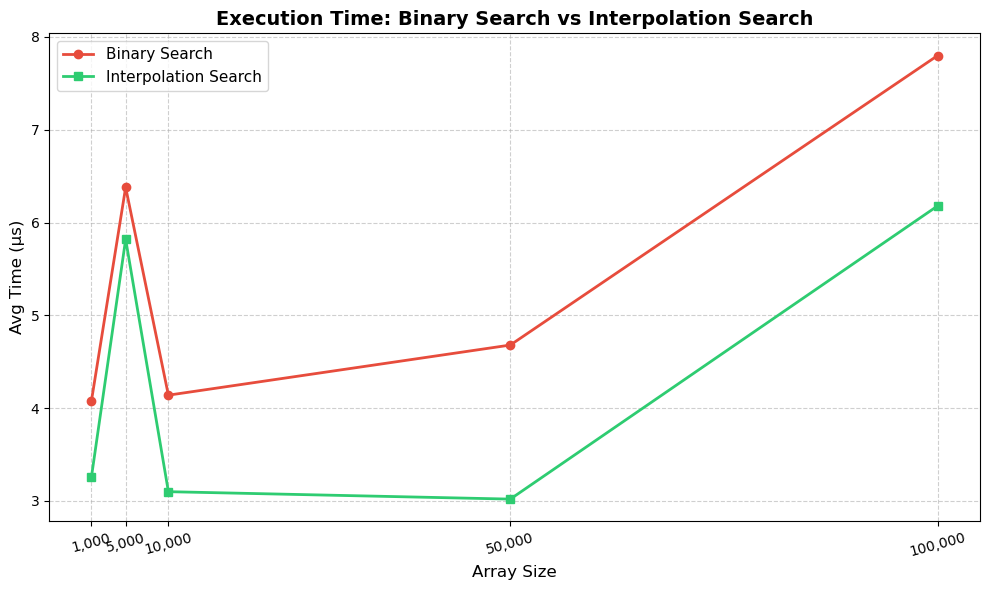

In [7]:
import random
import time
import matplotlib.pyplot as plt
from tabulate import tabulate



def binary_search(arr, key):
    comparisons = 0
    low, high = 0, len(arr) - 1

    while low <= high:
        mid = (low + high) // 2
        comparisons += 1

        if arr[mid] == key:
            return mid, comparisons
        elif arr[mid] < key:
            low = mid + 1
        else:
            high = mid - 1

    return -1, comparisons


def interpolation_search(arr, key):
    comparisons = 0
    low, high = 0, len(arr) - 1

    while low <= high and arr[low] <= key <= arr[high]:
        comparisons += 1

        if arr[low] == arr[high]:
            if arr[low] == key:
                return low, comparisons
            break

        pos = low + ((key - arr[low]) * (high - low) // (arr[high] - arr[low]))

        if arr[pos] == key:
            comparisons += 1
            return pos, comparisons
        elif arr[pos] < key:
            comparisons += 1
            low = pos + 1
        else:
            comparisons += 1
            high = pos - 1

    return -1, comparisons




def benchmark(sizes, runs=5):
    results = []
    bs_times, is_times = [], []

    for size in sizes:
        arr = sorted(random.sample(range(size * 10), size))
        key = random.choice(arr)          # guaranteed hit

        # --- Binary Search ---
        bs_comp_total, bs_time_total = 0, 0
        for _ in range(runs):
            start = time.perf_counter()
            _, comps = binary_search(arr, key)
            bs_time_total += time.perf_counter() - start
            bs_comp_total += comps

        bs_avg_time  = bs_time_total  / runs * 1e6   # µs
        bs_avg_comps = bs_comp_total  / runs

        # --- Interpolation Search ---
        is_comp_total, is_time_total = 0, 0
        for _ in range(runs):
            start = time.perf_counter()
            _, comps = interpolation_search(arr, key)
            is_time_total += time.perf_counter() - start
            is_comp_total += comps

        is_avg_time  = is_time_total  / runs * 1e6
        is_avg_comps = is_comp_total  / runs

        bs_times.append(bs_avg_time)
        is_times.append(is_avg_time)

        results.append([
            f"{size:,}",
            f"{bs_avg_time:.4f}",
            f"{int(bs_avg_comps)}",
            "O(log n)",
            "O(1)",
            f"{is_avg_time:.4f}",
            f"{int(is_avg_comps)}",
            "O(log log n)*",
            "O(1)",
        ])

    return results, bs_times, is_times




def display_table(results):
    headers = [
        "Array Size",
        "BS Time (µs)", "BS Comps", "BS Time Cmplx", "BS Space Cmplx",
        "IS Time (µs)", "IS Comps", "IS Time Cmplx", "IS Space Cmplx",
    ]
    print("\n" + "=" * 100)
    print(" PERFORMANCE COMPARISON: Binary Search vs Interpolation Search")
    print("=" * 100)
    print(tabulate(results, headers=headers, tablefmt="fancy_grid"))
    print("\n* O(log log n) for uniformly distributed data; O(n) worst case.")




def plot_results(sizes, bs_times, is_times):
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, bs_times, marker='o', linewidth=2, label='Binary Search',        color='#E74C3C')
    plt.plot(sizes, is_times, marker='s', linewidth=2, label='Interpolation Search', color='#2ECC71')

    plt.title('Execution Time: Binary Search vs Interpolation Search', fontsize=14, fontweight='bold')
    plt.xlabel('Array Size',      fontsize=12)
    plt.ylabel('Avg Time (µs)',   fontsize=12)
    plt.xticks(sizes, [f"{s:,}" for s in sizes], rotation=15)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
plt.savefig('search_comparison.png', dpi=150)
plt.show()
print("\nGraph saved as 'search_comparison.png'")




if __name__ == "__main__":
    sizes = [1000, 5000, 10000, 50000, 100000]

    print("Running benchmarks … please wait.")
    results, bs_times, is_times = benchmark(sizes)

    display_table(results)
    plot_results(sizes, bs_times, is_times)

    # Quick complexity summary
    print("\nComplexity Summary")
    print("-" * 45)
    print(f"{'Algorithm':<25} {'Time':<15} {'Space'}")
    print("-" * 45)
    print(f"{'Binary Search':<25} {'O(log n)':<15} {'O(1)'}")
    print(f"{'Interpolation Search':<25} {'O(log log n)*':<15} {'O(1)'}")
    print("-" * 45)
    print("* Best/average case on uniform data; worst case O(n).")